## Imports

In [1]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import cdist
from scipy.stats import hypergeom, kendalltau, pearsonr, wilcoxon
from tqdm.notebook import tqdm

from analysis_helpers import Episode, Participant
from analysis_helpers.functions import (
    auc, 
    bootstrap_ci, 
    dtw,
    format_stats, 
    hypergeom_mc_test, 
    mean_center, 
    rank_biserial, 
    rdp, 
    rdp_sweep, 
    removal_thresholds, 
    show_source
)

## Functions

In [2]:
show_source(rdp)

In [3]:
show_source(dtw)

In [4]:
show_source(format_stats)

In [5]:
show_source(mean_center)

In [6]:
def hypergeom_z(tp_obs, pool_size, n_good, n_draws):
    """
    Z-score an observed true-positive count against a hypergeometric 
    distribution.
    
    Parameters
    ----------
    tp_obs : int
        Observed true-positive count (successful draws) to z-score.
    pool_size : int
        Number of items in the pool to draw from.
    n_good : int
        Number of "success" items in the pool.
    n_draws : int
        Number of draws to make from the pool, without replacement.
        
    Returns
    -------
    float
        Z-score for for the observed true-positive count.
    """
    mean, var = hypergeom.stats(pool_size, n_good, n_draws, moments='mv')
    return (tp_obs - mean) / np.sqrt(var)

## Load data

In [7]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()

In [8]:
# center immediate & delayed recall on mean centroid to mitigate 
# person-specific register effects (idiolect, etc.)
imm_events_centered = []
del_events_centered = []
for p in participants:
    imm_centered, del_centered = mean_center(p.events['atlep1'], p.events['delayed'])
    imm_events_centered.append(imm_centered)
    del_events_centered.append(del_centered)

In [9]:
EPSILON_STEP = 0.01
EPSILONS = np.arange(0, 2, EPSILON_STEP).round(2)

df = pd.DataFrame(index=range(len(participants) * (len(EPSILONS))), 
                  columns=('participant', 
                           'epsilon', 
                           'n_events_removed', 
                           'n_events_remaining', 
                           'warp_cost'))
df['participant'] = np.repeat([f'P{p.sub_n}' for p in participants], len(EPSILONS))
df['epsilon'] = np.tile(EPSILONS, len(participants))

pbar = tqdm(total=len(df), leave=False)
df_ix = 0
for p_ix in range(len(participants)):
    imm_events = imm_events_centered[p_ix]
    del_events = del_events_centered[p_ix]

    # un-simplified alignment cost (baseline)
    n_events_orig = len(imm_events)
    n_events_remaining = n_events_orig
    n_events_removed = 0
    warp_cost = dtw(imm_events, del_events, metric='cosine', norm_cost=True)[0]
    df.loc[df_ix, 'n_events_removed':'warp_cost'] = (n_events_removed, 
                                                     n_events_remaining, 
                                                     warp_cost)
    df_ix += 1
    pbar.update()
    
    for epsilon in EPSILONS[1:]:
        imm_simplified = rdp(imm_events, epsilon=epsilon, metric='cosine')
        if len(imm_simplified) != n_events_remaining:
            n_events_remaining = len(imm_simplified)
            n_events_removed = n_events_orig - n_events_remaining
            warp_cost = dtw(imm_simplified, 
                            del_events, 
                            metric='cosine', 
                            norm_cost=True)[0]
        
        df.loc[df_ix, 'n_events_removed':'warp_cost'] = (n_events_removed, 
                                                         n_events_remaining, 
                                                         warp_cost)
        df_ix += 1
        pbar.update()
        
        if n_events_remaining == 2:
            last_p_row = df.index[df['participant'] == f'P{p_ix + 1}'][-1].item()
            df.loc[
                df_ix:last_p_row, 'n_events_removed':'warp_cost'
            ] = (n_events_removed, n_events_remaining, warp_cost)
            df_ix = last_p_row + 1
            pbar.update(df_ix - pbar.n)
            break
            
df = df.astype({'participant': str, 
                'epsilon': float, 
                'n_events_removed': int, 
                'n_events_remaining': int, 
                'warp_cost': float})
pbar.close()

  0%|          | 0/10600 [00:00<?, ?it/s]

In [10]:
best_alignments = (
    df.loc[
        df.groupby('participant')['warp_cost'].idxmin(), [
            'participant', 
            'epsilon', 
            'n_events_removed', 
            'n_events_remaining', 
            'warp_cost'
        ]
    ]
    .sort_values(
        by='participant', key=lambda pid: pid.str.removeprefix('P').astype(int)
    )
    .reset_index(drop=True)
)

best_alignments['n_events_imm'] = [len(p.events['atlep1']) for p in participants]
best_alignments['n_events_del'] = [len(p.events['delayed']) for p in participants]
best_alignments['n_events_decrease'] = best_alignments['n_events_imm'] - best_alignments['n_events_del']

best_alignments.head()

,participant,epsilon,n_events_removed,n_events_remaining,warp_cost,n_events_imm,n_events_del,n_events_decrease
0,P1,0.42,1,22,0.558993,23,19,4
1,P2,0.00,0,14,0.549072,14,16,-2
2,P3,0.29,1,19,0.468923,20,18,2
3,P4,0.00,0,19,0.397291,19,18,1
4,P5,0.00,0,18,0.466080,18,19,-1


best-fitting tolerance: median=0.00, range=[0.00, 0.82], zero for 27 of 53 participants
events removed at that tolerance: median=0, mean=1.00


<Axes: xlabel='epsilon', ylabel='Count'>

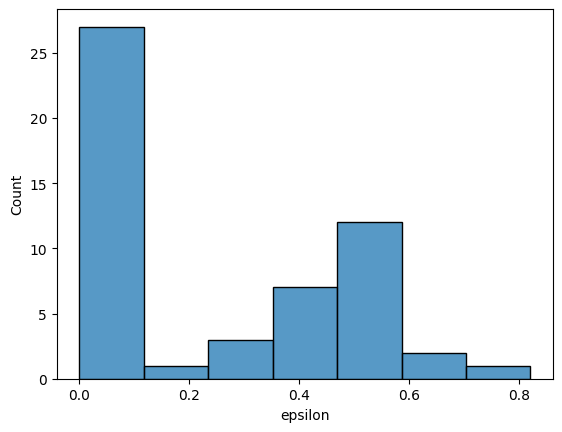

In [11]:
eps = best_alignments['epsilon']
removed = best_alignments['n_events_removed']

# ties in warp cost are resolved in favor of the smallest tolerance, so a zero
# here records the absence of an improvement rather than a positive fit at 0
print(f'best-fitting tolerance: median={eps.median():.2f}, '
      f'range=[{eps.min():.2f}, {eps.max():.2f}], '
      f'zero for {(eps == 0).sum()} of {len(eps)} participants')
print(f'events removed at that tolerance: median={removed.median():.0f}, '
      f'mean={removed.mean():.2f}')

sns.histplot(eps)

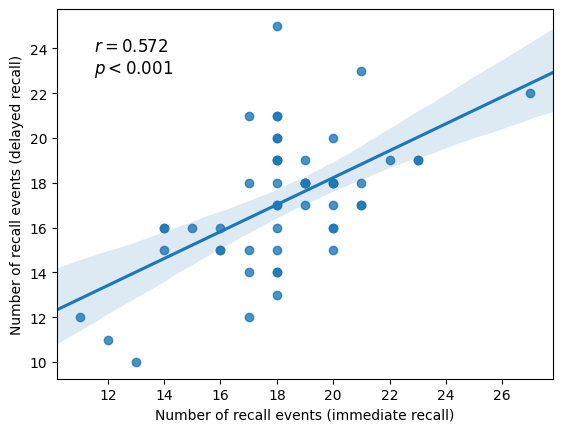

In [12]:
ax = sns.regplot(best_alignments, 
                 x='n_events_imm', 
                 y='n_events_del', 
                 truncate=False)
r, p = pearsonr(best_alignments['n_events_imm'], best_alignments['n_events_del'])
stats_fmt = format_stats(r, p, 'r')
ax.text(0.075, 0.925, 
        stats_fmt, 
        ha='left', 
        va='top', 
        transform=ax.transAxes, 
        fontsize=12)
ax.set_xlabel('Number of recall events (immediate recall)')
ax.set_ylabel('Number of recall events (delayed recall)')
plt.show()

tau=0.518, p=3.4601e-06, 95% CI [0.356, 0.658], n=53


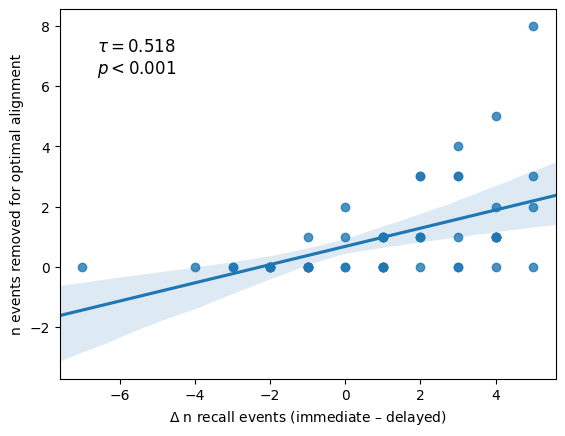

In [13]:
ax = sns.regplot(best_alignments, 
                 x='n_events_decrease',
                 y='n_events_removed', 
                 truncate=False)
tau, p = kendalltau(best_alignments['n_events_decrease'], 
                    best_alignments['n_events_removed'])
pairs = best_alignments[['n_events_decrease', 'n_events_removed']].to_numpy(dtype=float)
ci_lo, ci_hi = bootstrap_ci(pairs, lambda xy: kendalltau(xy[:, 0], xy[:, 1]).statistic)
print(f'tau={tau:.3f}, p={p:.4e}, 95% CI [{ci_lo:.3f}, {ci_hi:.3f}], '
      f'n={len(best_alignments)}')
stats_fmt = format_stats(tau, p, '\\tau')
ax.text(0.075, 0.925, 
        stats_fmt, 
        ha='left', 
        va='top', 
        transform=ax.transAxes, 
        fontsize=12)
ax.set_xlabel('$\\Delta$ n recall events (immediate – delayed)')
ax.set_ylabel('n events removed for optimal alignment')
plt.show()

tau=0.457, p=1.9037e-05, 95% CI [0.289, 0.608], n=53


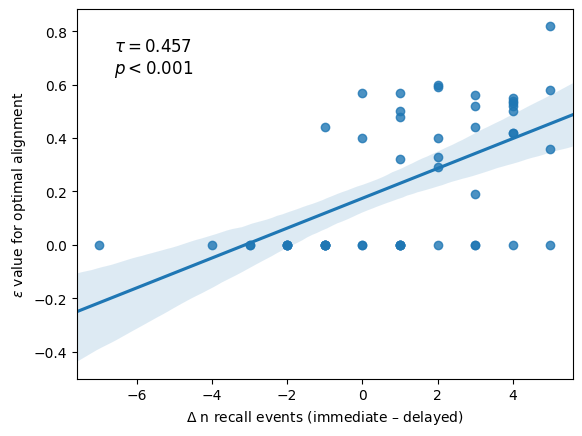

In [14]:
ax = sns.regplot(best_alignments, 
                 x='n_events_decrease', 
                 y='epsilon', 
                 truncate=False)
tau, p = kendalltau(best_alignments['n_events_decrease'], 
                    best_alignments['epsilon'])
pairs = best_alignments[['n_events_decrease', 'epsilon']].to_numpy(dtype=float)
ci_lo, ci_hi = bootstrap_ci(pairs, lambda xy: kendalltau(xy[:, 0], xy[:, 1]).statistic)
print(f'tau={tau:.3f}, p={p:.4e}, 95% CI [{ci_lo:.3f}, {ci_hi:.3f}], '
      f'n={len(best_alignments)}')
stats_fmt = format_stats(tau, p, '\\tau')
ax.text(0.075, 0.925, 
        stats_fmt, 
        ha='left', 
        va='top', 
        transform=ax.transAxes, 
        fontsize=12)
ax.set_xlabel('$\\Delta$ n recall events (immediate – delayed)')
ax.set_ylabel('$\\epsilon$ value for optimal alignment')
plt.show()

In [15]:
newcols = [
    'rdp_pred_forgotten', 
    'true_forgotten',
    'true_positives',
    'false_positives',
    'true_negatives',
    'false_negatives'
]
best_alignments[newcols] = np.nan
best_alignments[['rdp_pred_forgotten', 'true_forgotten']] = best_alignments[
    ['rdp_pred_forgotten', 'true_forgotten']
].astype(object)


for ix, row in best_alignments.iterrows():
    p = participants[ix]
    imm_events = imm_events_centered[ix]
    imm_event_matches = p.event_matches['atlep1']
    del_event_matches = p.event_matches['delayed']
    
    imm_simplified, rec_events_retained = rdp(imm_events, 
                                              epsilon=row['epsilon'], 
                                              metric='cosine', 
                                              return_indices=True)
    ep_events_dropped_rdp = np.delete(imm_event_matches, rec_events_retained)
    pred_forgotten = set(ep_events_dropped_rdp.tolist())
    # events should be deduplicated for analysis, but no duplicates 
    # actually exist in the first place:
    np.testing.assert_array_equal(sorted(ep_events_dropped_rdp), sorted(pred_forgotten))
    best_alignments.at[ix, 'rdp_pred_forgotten'] = pred_forgotten
    
    # exclude first & last immediate recall events since RDP will never
    # remove first or last point
    imm_rec_counts = Counter(imm_event_matches[1:-1].tolist())
    del_rec_counts = Counter(del_event_matches.tolist())
    true_forgotten = set((imm_rec_counts - del_rec_counts).keys())
    best_alignments.at[ix, 'true_forgotten'] = true_forgotten
    
    best_alignments.loc[ix, 'true_positives':'false_negatives'] = (
        # true pos: predicted forgotten & forgotten
        len(pred_forgotten & true_forgotten),
        # false pos: predicted forgotten & not forgotten
        len(pred_forgotten - true_forgotten),
        # true neg: not predicted forgotten & not forgotten
        len(set(imm_rec_counts.keys()) - true_forgotten - pred_forgotten),
        # false neg: forgotten & not predicted forgotten
        len(true_forgotten - pred_forgotten)
    )

best_alignments[
    ['true_positives', 'false_positives', 'true_negatives', 'false_negatives']
] = best_alignments[
    ['true_positives', 'false_positives', 'true_negatives', 'false_negatives']
].astype(int)

best_alignments.head()

,participant,epsilon,n_events_removed,n_events_remaining,warp_cost,n_events_imm,n_events_del,n_events_decrease,rdp_pred_forgotten,true_forgotten,true_positives,false_positives,true_negatives,false_negatives
0,P1,0.42,1,22,0.558993,23,19,4,{1},"{10, 4, 13}",0,1,14,3
1,P2,0.00,0,14,0.549072,14,16,-2,{},"{9, 12}",0,0,10,2
2,P3,0.29,1,19,0.468923,20,18,2,{9},"{9, 13}",1,0,16,1
3,P4,0.00,0,19,0.397291,19,18,1,{},"{13, 14}",0,0,14,2
4,P5,0.00,0,18,0.466080,18,19,-1,{},"{13, 4, 12}",0,0,13,3


PearsonRResult(statistic=np.float64(0.517581357686006), pvalue=np.float64(7.221205275103454e-05))

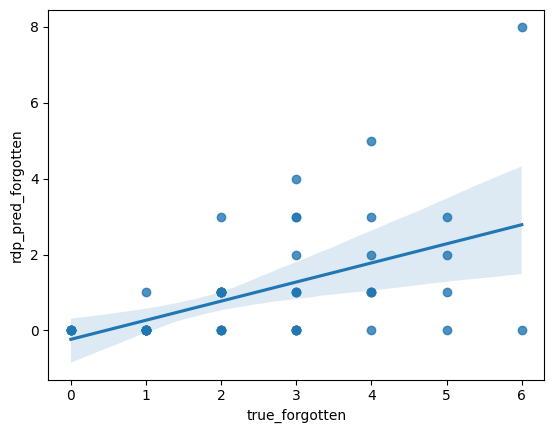

In [16]:
sns.regplot(x=best_alignments['true_forgotten'].apply(len), 
            y=best_alignments['rdp_pred_forgotten'].apply(len))
pearsonr(best_alignments['true_forgotten'].apply(len), best_alignments['rdp_pred_forgotten'].apply(len))

## Analysis 1

recall events correctly identified: 22 in total, against 12.9 expected by chance, p=7.9992e-04 (Monte Carlo test over 10,000 hypergeometric draws)
per participant: mean excess=0.172 events, 95% CI [0.064, 0.287], n=53


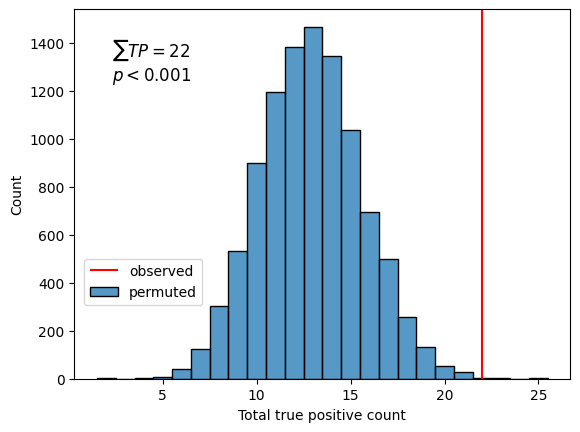

In [17]:
# number of immediate recall events (excluding endpoints)
n_imm_events = best_alignments.loc[:, 'true_positives':'false_negatives'].sum(axis=1).to_numpy()
# number of events actually forgotten
n_true_forgotten = best_alignments[['true_positives', 'false_negatives']].sum(axis=1).to_numpy()
# number of events predicted to be forgotten
n_pred_forgotten = best_alignments[['true_positives', 'false_positives']].sum(axis=1).to_numpy()

obs_tpsum, expected, p, null_tpsums = hypergeom_mc_test(
    n_true_forgotten, 
    n_imm_events - n_true_forgotten, 
    n_pred_forgotten, 
    best_alignments['true_positives']
)

# the excess over the analytic hypergeometric mean, for an effect size with an
# interval on it
expected_each = n_true_forgotten * n_pred_forgotten / n_imm_events
excess = best_alignments['true_positives'].to_numpy() - expected_each
ci_lo, ci_hi = bootstrap_ci(excess, np.mean)

print(f'recall events correctly identified: {obs_tpsum} in total, against '
      f'{expected:.1f} expected by chance, p={p:.4e} '
      f'(Monte Carlo test over {len(null_tpsums):,} hypergeometric draws)')
print(f'per participant: mean excess={excess.mean():.3f} events, '
      f'95% CI [{ci_lo:.3f}, {ci_hi:.3f}], n={len(participants)}')

ax = sns.histplot(null_tpsums, discrete=True, label='permuted')
ax.set_ylim(ax.get_ylim())
ax.vlines(obs_tpsum, *ax.get_ylim(), color='r', label='observed')
ax.legend(loc=(0.02, 0.2))
stats_fmt = format_stats(obs_tpsum, p, '\\sum TP', n_decimals_stat=0)
ax.text(0.075, 0.925, 
        stats_fmt, 
        ha='left', 
        va='top', 
        transform=ax.transAxes, 
        fontsize=12)
ax.set_xlabel('Total true positive count')
plt.show()

### A matched null for how $\epsilon$ is chosen

The test above holds the number of predicted events fixed and asks whether their *identity* beats
chance. That controls for how many events simplification removes, but not for how the tolerance was
chosen: $\epsilon$ is selected by aligning against the same delayed trajectory whose omissions are
then predicted, so the selection has already seen the outcome.

A hypergeometric null cannot see that, because it treats the removed set as a random draw. Neither
does Analysis 2 below, which substitutes *other participants'* predicted-forgotten sets and so
varies the trajectory and the selection together.

The matched null changes one thing only. Each participant's own trajectory is held fixed, and with
it every candidate simplification --- which points RDP removes is a property of the path's own
shape, so the only step at which outside information can enter is the choice among candidates. That
choice is then made against **another participant's** delayed trajectory, and scored against the
target participant's own forgotten events.

Choosing $\epsilon$ against the wrong delayed trajectory also changes how many events get removed,
so raw hit counts are not comparable between the two conditions. Each is instead expressed as a
ratio of observed true positives to its own hypergeometric expectation, which is 1.0 when
simplification carries no information about forgetting.

In [18]:
def predicted_forgotten(kept, event_matches, pool):
    """Episode events that simplification dropped, restricted to `pool`."""
    dropped = np.setdiff1d(np.arange(len(event_matches)), kept)
    return set(event_matches[dropped].tolist()) & pool


def hits_and_expectation(target_ix, delayed_events):
    """
    Score one participant's prediction when the tolerance is chosen by aligning
    their own simplifications to `delayed_events`, which need not be their own
    delayed trajectory. Returns the true-positive count and the hypergeometric
    expectation for it.
    """
    candidates, event_matches, pool, forgotten = participant_candidates[target_ix]
    costs = [dtw(simplified, delayed_events, metric='cosine', norm_cost=True)[0]
             for _, simplified, _ in candidates]
    kept = candidates[int(np.argmin(costs))][2]
    predicted = predicted_forgotten(kept, event_matches, pool)
    expected = len(forgotten) * len(predicted) / len(pool)
    return len(predicted & forgotten), expected

In [19]:
# every candidate simplification of each participant's immediate trajectory,
# alongside what they actually forgot. Endpoints are excluded throughout, since
# RDP never removes the first or last point of a trajectory.
participant_candidates = []
for p_ix, p in enumerate(tqdm(participants, leave=False)):
    event_matches = p.event_matches['atlep1']
    pool = set(event_matches[1:-1].tolist())
    forgotten = set((Counter(event_matches[1:-1].tolist())
                     - Counter(p.event_matches['delayed'].tolist())).keys())
    participant_candidates.append(
        (rdp_sweep(imm_events_centered[p_ix], EPSILONS), event_matches, pool, forgotten)
    )

  0%|          | 0/53 [00:00<?, ?it/s]

In [20]:
own_hits = own_expected = 0
for p_ix in range(len(participants)):
    hits, expected = hits_and_expectation(p_ix, del_events_centered[p_ix])
    own_hits += hits
    own_expected += expected
own_ratio = own_hits / own_expected

surrogate_ratios = []
for surrogate_ix in tqdm(range(len(participants)), leave=False):
    hits = expected = 0
    for p_ix in range(len(participants)):
        if p_ix == surrogate_ix:
            continue
        h, e = hits_and_expectation(p_ix, del_events_centered[surrogate_ix])
        hits += h
        expected += e
    surrogate_ratios.append(hits / expected)

surrogate_ratios = np.array(surrogate_ratios)
p = ((surrogate_ratios >= own_ratio).sum() + 1) / (len(surrogate_ratios) + 1)

print(f'own delayed trajectory chooses epsilon:       {own_hits} hits, '
      f'{own_expected:.1f} expected, ratio={own_ratio:.2f}')
print(f'surrogate delayed trajectory chooses epsilon: ratio '
      f'mean={surrogate_ratios.mean():.2f}, s.d.={surrogate_ratios.std(ddof=1):.2f}, '
      f'range=[{surrogate_ratios.min():.2f}, {surrogate_ratios.max():.2f}]')
print(f'own vs surrogate distribution: p={p:.4f}, n={len(participants)} surrogates')

  0%|          | 0/53 [00:00<?, ?it/s]

own delayed trajectory chooses epsilon:       22 hits, 12.9 expected, ratio=1.70
surrogate delayed trajectory chooses epsilon: ratio mean=1.27, s.d.=0.17, range=[0.98, 1.63]
own vs surrogate distribution: p=0.0185, n=53 surrogates


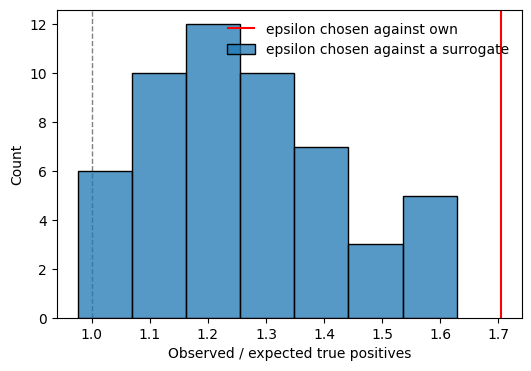

In [21]:
fig, ax = plt.subplots(1, figsize=(6, 4))
sns.histplot(surrogate_ratios, ax=ax, label='epsilon chosen against a surrogate')
ax.set_ylim(ax.get_ylim())
ax.vlines(own_ratio, *ax.get_ylim(), color='r', label='epsilon chosen against own')
ax.axvline(1, c='grey', ls='--', lw=1, zorder=0)
ax.set_xlabel('Observed / expected true positives')
ax.legend(frameon=False)
plt.show()

## Analysis 2

In [22]:
own_tp_zs = []
other_tp_zs = []
included_participants = []

for ix, row in best_alignments.iterrows():
    p = participants[ix]
    own_pred_forgotten = row['rdp_pred_forgotten']
    true_forgotten = row['true_forgotten']
    
    # only consider participants who actually forgot and were predicted 
    # to forget at least 1 event
    if len(own_pred_forgotten) == 0 or len(true_forgotten) == 0:
        continue
        
    own_tp = row['true_positives']
    pool = set(p.event_matches['atlep1'][1:-1])  # excluding endpoints
    own_tp_z = hypergeom_z(own_tp, 
                           len(pool), 
                           len(true_forgotten), 
                           len(own_pred_forgotten))
    own_tp_zs.append(own_tp_z)
    included_participants.append(p)
    
    _other_tp_zs = []
    for other_ix, other_row in best_alignments.iterrows():
        if other_ix == ix:
            continue
            
        # restrict predicted-forgotten events to those the target 
        # participant recalled (not-recalled events can't be predicted 
        # to be forgotten)
        other_pred_forgotten = other_row['rdp_pred_forgotten'] & pool
        # only consider surrogate participants who were predicted to 
        # forget at least 1 event the target participant recalled (and 
        # so could have forgotten) so own-predictions aren't competing 
        # against artificially poor other-predictions
        if len(other_pred_forgotten) == 0:
            continue
        
        other_tp = len(other_pred_forgotten & true_forgotten)
#         with warnings.catch_warnings():
#             warnings.simplefilter('error')
        other_tp_z = hypergeom_z(other_tp, 
                                 len(pool), 
                                 len(true_forgotten), 
                                 len(other_pred_forgotten))
        _other_tp_zs.append(other_tp_z)
        
    other_tp_zs.append(_other_tp_zs)
    
own_tp_zs = np.array(own_tp_zs)

pct_ranks = np.empty(len(own_tp_zs))
for i, own in enumerate(own_tp_zs):
    other = np.asarray(other_tp_zs[i])
    pct_ranks[i] = ((own > other).sum() + (own == other).sum() * 0.5) / len(other)

T, p = wilcoxon(pct_ranks, 0.5, alternative='greater')
r = rank_biserial(pct_ranks - 0.5)
ci_lo, ci_hi = bootstrap_ci(pct_ranks)

print(f'T={T.item()}, p={p.item():.4e} (one-sided), rank-biserial r={r:.3f}')
print(f'median percentile rank={np.median(pct_ranks):.3f}, '
      f'95% CI [{ci_lo:.3f}, {ci_hi:.3f}], n={len(included_participants)}')

T=272.0, p=7.1229e-03 (one-sided), rank-biserial r=0.550
median percentile rank=0.714, 95% CI [0.523, 0.840], n=26


## Analysis 3

Analyses 1 and 2 ask about a *set*: at one tolerance, are the events simplification removes the
events that were forgotten? A stronger reading of the same idea is that simplification *grades*
events --- that the tolerance an event survives to measures how expendable it is, so events removed
early should be likelier to go than events removed late.

That quantity involves no tolerance selection and no information about the delayed recall at all,
which makes it the cleanest test of the idea. For each participant we take the tolerance at which
each of their immediate recall events is first removed, average over recall events describing the
same episode event, and ask whether the events they went on to forget were removed at lower
tolerances than the ones they kept.

AUC rather than a difference of means, since participants contribute very different numbers of
forgotten and retained events, and two-sided, since the geometry does not guarantee a direction.

In [23]:
expendability_aucs = []
for p_ix, p in enumerate(tqdm(participants, leave=False)):
    event_matches = p.event_matches['atlep1']
    thresholds = removal_thresholds(imm_events_centered[p_ix], EPSILONS)

    # one score per episode event, averaged over the recall events describing it
    scores = {}
    for rec_ix in range(1, len(event_matches) - 1):
        scores.setdefault(event_matches[rec_ix].item(), []).append(thresholds[rec_ix])
    scores = {ep_event: np.mean(vals) for ep_event, vals in scores.items()}

    forgotten = set((Counter(event_matches[1:-1].tolist())
                     - Counter(p.event_matches['delayed'].tolist())).keys())
    was_forgotten = [v for k, v in scores.items() if k in forgotten]
    was_kept = [v for k, v in scores.items() if k not in forgotten]
    if not was_forgotten or not was_kept:
        # no contrast to measure for this participant
        continue
    expendability_aucs.append(auc(was_forgotten, was_kept, smaller_is_positive=True))

expendability_aucs = np.array(expendability_aucs)
T, p = wilcoxon(expendability_aucs, 0.5)
ci_lo, ci_hi = bootstrap_ci(expendability_aucs, np.mean)

print(f'participants contributing: {len(expendability_aucs)} of {len(participants)}')
print(f'AUC: mean={expendability_aucs.mean():.3f}, median={np.median(expendability_aucs):.3f}, '
      f'95% CI [{ci_lo:.3f}, {ci_hi:.3f}]')
print(f'vs chance (0.5): T={T.item()}, p={p.item():.4f} (two-sided), '
      f'rank-biserial r={rank_biserial(expendability_aucs - 0.5):.3f}')

  0%|          | 0/53 [00:00<?, ?it/s]

participants contributing: 47 of 53
AUC: mean=0.545, median=0.538, 95% CI [0.491, 0.600]
vs chance (0.5): T=374.0, p=0.1579 (two-sided), rank-biserial r=0.244


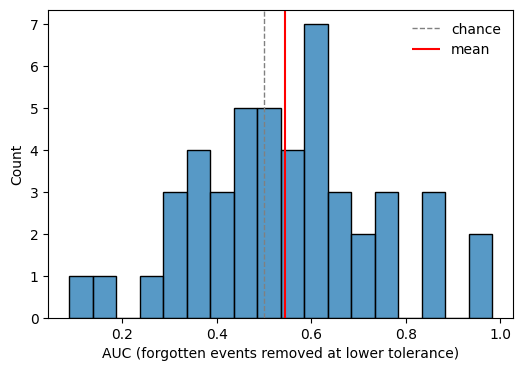

In [24]:
fig, ax = plt.subplots(1, figsize=(6, 4))
sns.histplot(expendability_aucs, binwidth=0.05, ax=ax)
ax.set_ylim(ax.get_ylim())
ax.vlines(0.5, *ax.get_ylim(), color='grey', ls='--', lw=1, label='chance')
ax.vlines(expendability_aucs.mean(), *ax.get_ylim(), color='r', label='mean')
ax.set_xlabel('AUC (forgotten events removed at lower tolerance)')
ax.legend(frameon=False)
plt.show()